In [1]:
#Medical Insurance Cost Prediction using Decision Tree Regression

#Author: Manikandaprabhu.S  
#Objective: To build a Decision Tree Regression model to predict medical insurance costs based on demographic and health-related features.

In [2]:
## 1. Importing Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
## 2. Loading the Dataset
dataset = pd.read_csv("insurance_pre.csv")
pd.options.display.max_rows = 10
dataset

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830
1334,18,female,31.920,0,no,2205.98080
1335,18,female,36.850,0,no,1629.83350
1336,21,female,25.800,0,no,2007.94500


In [4]:
## 3. Data Preprocessing (Handling Categorical Variables)
data = pd.get_dummies(dataset,dtype=int)
data

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes
0,19,27.900,0,16884.92400,1,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0
2,28,33.000,3,4449.46200,0,1,1,0
3,33,22.705,0,21984.47061,0,1,1,0
4,32,28.880,0,3866.85520,0,1,1,0
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,0,1,1,0
1334,18,31.920,0,2205.98080,1,0,1,0
1335,18,36.850,0,1629.83350,1,0,1,0
1336,21,25.800,0,2007.94500,1,0,1,0


In [5]:
## 4. Exploratory Data Inspection
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         1338 non-null   int64  
 1   bmi         1338 non-null   float64
 2   children    1338 non-null   int64  
 3   charges     1338 non-null   float64
 4   sex_female  1338 non-null   int64  
 5   sex_male    1338 non-null   int64  
 6   smoker_no   1338 non-null   int64  
 7   smoker_yes  1338 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 83.8 KB


In [6]:
data.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_female', 'sex_male',
       'smoker_no', 'smoker_yes'],
      dtype='object')

In [7]:
## 5. Preparing Features and Target Variable
Features = data[['age', 'bmi', 'children','sex_male','smoker_yes']]
Target = data[['charges']].values.ravel()
Features

,age,bmi,children,sex_male,smoker_yes
0,19,27.900,0,0,1
1,18,33.770,1,1,0
2,28,33.000,3,1,0
3,33,22.705,0,1,0
4,32,28.880,0,1,0
...,...,...,...,...,...
1333,50,30.970,3,1,0
1334,18,31.920,0,0,0
1335,18,36.850,0,0,0
1336,21,25.800,0,0,0


In [8]:
## 6. Splitting Dataset into Training and Testing Sets
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(Features,Target,test_size=1/3,random_state=0)
x_train

,age,bmi,children,sex_male,smoker_yes
482,18,31.35,0,0,0
338,50,32.30,1,1,1
356,46,43.89,3,1,0
869,25,24.30,3,0,0
182,22,19.95,3,1,0
...,...,...,...,...,...
763,27,26.03,0,1,0
835,42,35.97,2,1,0
1216,40,25.08,0,1,0
559,19,35.53,0,1,0


In [9]:
## 7. Feature Scaling (Important for Decision Tree)

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)
x_test


array([[ 0.89108031, -0.07576237, -0.0755796 ,  1.01127431, -0.49929923],
       [ 0.5336223 , -0.21009861, -0.0755796 , -0.98885138, -0.49929923],
       [ 0.6051139 ,  1.60182214,  0.75672907,  1.01127431,  2.00280702],
       ...,
       [-1.46814257,  0.65256665,  0.75672907, -0.98885138,  2.00280702],
       [-0.82471815,  0.37742013,  1.58903774,  1.01127431, -0.49929923],
       [ 0.89108031,  1.24817794,  0.75672907, -0.98885138, -0.49929923]],
      shape=(446, 5))

In [10]:
## 8. Training Decision Tree Model with Hyperparameter Tuning (GridSearchCV)
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
param_grid = {'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],'max_features': ['sqrt', 'log2', None],'splitter': ['best', 'random'],'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10]}

grid = GridSearchCV(DecisionTreeRegressor(), param_grid, refit = True, verbose= 3,n_jobs=-1)

grid.fit(x_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'absolute_error', ...], 'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'friedman_mse'


In [11]:
## 9. Hyperparameter Results Analysis

re=grid.cv_results_
print("The R_score value for best parameter {}:".format(grid.best_params_))

The R_score value for best parameter {'criterion': 'friedman_mse', 'max_depth': 3, 'max_features': None, 'min_samples_split': 5, 'splitter': 'best'}:


In [12]:
table=pd.DataFrame.from_dict(re)
table

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_features,param_min_samples_split,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.002756,0.000708,0.002429,0.000131,squared_error,3,sqrt,2,best,"{'criterion': 'squared_error', 'max_depth': 3,...",0.335387,0.601231,0.765297,0.816175,0.679188,0.639456,0.168857,157
1,0.001576,0.000361,0.002119,0.000930,squared_error,3,sqrt,2,random,"{'criterion': 'squared_error', 'max_depth': 3,...",0.669421,0.286720,0.213057,0.651134,0.601775,0.484422,0.194172,207
2,0.002622,0.000701,0.002043,0.000992,squared_error,3,sqrt,5,best,"{'criterion': 'squared_error', 'max_depth': 3,...",0.486293,0.728998,0.864072,0.516289,0.701512,0.659433,0.140680,143
3,0.002388,0.001290,0.002131,0.001720,squared_error,3,sqrt,5,random,"{'criterion': 'squared_error', 'max_depth': 3,...",0.141105,0.503980,0.660847,0.599129,0.661259,0.513264,0.194754,200
4,0.002128,0.000596,0.002813,0.000280,squared_error,3,sqrt,10,best,"{'criterion': 'squared_error', 'max_depth': 3,...",0.646329,0.727714,0.711109,0.203594,0.400794,0.537908,0.204131,192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,0.002088,0.000285,0.001416,0.000854,friedman_mse,10,None,2,random,"{'criterion': 'friedman_mse', 'max_depth': 10,...",0.778867,0.757897,0.758550,0.640180,0.673298,0.721758,0.054634,87
212,0.003287,0.000787,0.001265,0.001060,friedman_mse,10,None,5,best,"{'criterion': 'friedman_mse', 'max_depth': 10,...",0.719393,0.550692,0.811143,0.682668,0.705766,0.693933,0.083870,117
213,0.001372,0.000578,0.001477,0.000787,friedman_mse,10,None,5,random,"{'criterion': 'friedman_mse', 'max_depth': 10,...",0.751126,0.773751,0.797188,0.751131,0.683565,0.751352,0.037942,61
214,0.002743,0.000625,0.001070,0.000815,friedman_mse,10,None,10,best,"{'criterion': 'friedman_mse', 'max_depth': 10,...",0.752267,0.617176,0.807280,0.687816,0.729319,0.718772,0.063791,95


In [13]:
## 10. Model Evaluation
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

y_pred = grid.predict(x_test) 

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)
n = x_test.shape[0]  
p = x_test.shape[1]   
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("R2 Score:", r2)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("Mean Absolute Error:", mae)
print("Adjusted R2 Score:", adjusted_r2)

R2 Score: 0.8742930260385806
Mean Squared Error: 20155252.895239014
Root Mean Squared Error: 4489.460200874824
Mean Absolute Error: 2761.9734961608874
Adjusted R2 Score: 0.8728645376981099


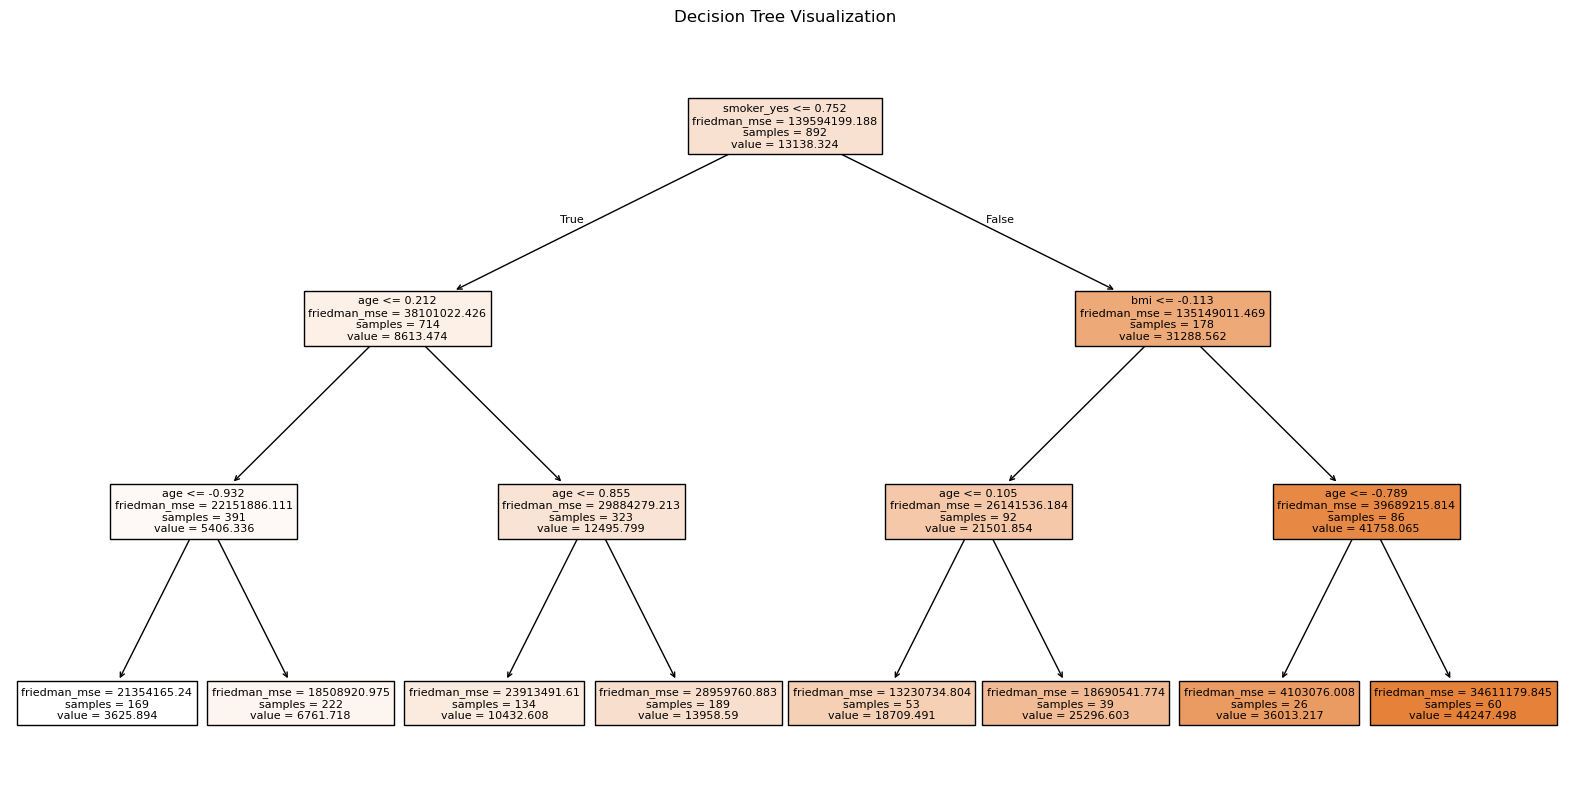

In [14]:
## 11. Visualizing Model Performance
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
best_model = grid.best_estimator_

plot_tree(best_model,feature_names=['age', 'bmi', 'children', 'sex_male', 'smoker_yes'],filled=True)

plt.title("Decision Tree Visualization")
plt.show()

In [15]:
## 12. Saving the Trained Model and Scaler
best_model = grid.best_estimator_

import pickle

# Save scaler
pickle.dump(sc, open("scaler_DT.pkl", "wb"))

# Save model
pickle.dump(best_model, open("Finalized_DT_model.sav", "wb"))

In [16]:
## Conclusion:

#- Implemented Decision Tree Regressor to predict medical insurance costs.
#- Model captures non-linear relationships between features and target effectively.
#- No feature scaling required, making preprocessing simpler compared to SVR.
#- Tends to overfit the training data if not properly controlled (e.g., max_depth).
#- Provides clear interpretability through feature importance.
#- Performance is good but may be less stable compared to ensemble methods like Random Forest.